# E-Commerce Agentic Bots
1. 📦 Global Products Agent
- `Tools:` Web Scrapes from popular webpages such as Amazon, Spotify in `json-like format`
- `Description:` Writes a description about each product as well as their price, adhers to a specific pydantic format
- `PDF:` Saves Description about each item in a single PDF report, that can be vectorised and stored in a `vector database`

2. 🐼Chinese Latest Trend Agent
- `Tools:` API tools that fetches in `json-like format` or use `Tarvily` for web search smartly, an optimisted web-search library for LLM
- `Description:` Writes a summary about the latest news in china regarding products, general trends
- `PDF:` Saves the summary in a single PDF report, that can be vectorised and stored in a `vector database`

3. 🏛️📜Chinese Legal Platform, Commerical, Legal laws Agent
- `Tools:` uses `Tarvily` for web search smartly
- `Description:` Saves all these legal laws in a single document without reading them
- `PDF:` Saves all legal information in a single PDF report, that can be vectorised and stored in a `vector database`

4. ⛩️Chinese Cultural Nuance Creator Agent
- `Tools:` Access all PDF reports using `RAG` to generate a general report for chinese audience
- `PDF:` Saves a PDF report, that can be vectorised and stored in a `vector database`

5. 🎥Platform Specific Agent
- `Tools:` Access PDF generated by `Chinese Cultural Nuance Creator Agent` using `RAG` technique
- `Generation:` Generates a script for each specific platform separately

6. 🏮Translator Agent
- `Tools:` Access PDF generated by  Platform Specific Agent, translates it into several chinese dialects including Mandarin

# Product Agent
1. Webpages to scrape `http://books.toscrape.com/`
2. Made up of 3 Nodes (Web Scrapping)
    - Node A (Fetch and Minimise) given a webpage to be scrapped, it will scrape it and using soap to remove header, ads,  style, script, etc.. then convert it to `MarkDown` format instead of `html` , `MarkDown` is recommended format of data to be fed to agent
    - Node B (Extract) feeding output from Node A to Node B to and ask it to adhere to defined Product Schema
    - Node C (The Router/Validator) loops back to Node A if it did not successfully fetch data
3. Records How many calls, time taken to finish the task, also things that slowed down agent while working
4. API to be called `https://api.escuelajs.co/api/v1/products`
5. Made up of 2 Nodes (API)
    - Node A (Fetch and Match) given API json data, some of titles might not match with data, agent job is to make it match with current schema
    - Node B (The Router/Validator) loops back to Node A if it did not successfully fetch data
6. Records How many calls, time taken to finish the task, also things that slowed down agent while working

    

# Improve Version

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [24]:
from pydantic import BaseModel, Field
from typing import List, Literal, Optional
from typing_extensions import Annotated, TypedDict
from langgraph.graph.message import add_messages
import operator
from requests import request
from bs4 import BeautifulSoup
from html_to_markdown import convert
import time


class Product(BaseModel):
    name: str
    price: float
    description: str
    category: str | None = Field(
        description="The product category extracted from the webpage. If not explicitly mentioned, generate a suitable, general category name."
    )    
    rating: float | None = Field(description="extract the rating of the product if it only exists, , that comes from the content of the webpage, do not make it up")
    source_address: str | None = Field(description="The URL or physical address where this content was extracted.")

class ProductCatalog(BaseModel):
    products : List[Product] = Field(description="A list of e-commerce products")

class ProductSchema(BaseModel):
    type_url_data : Literal["json","html"] = Field(description="Based on current_url if it has api word in it assume it returns 'json' else 'html'")
    url_list : list[str] = Field(description="given a message extract urls only from that message and store them in array")
    work_status: Literal["inprogress","finished"] = Field(description="If processed_url_list is equal to url_list return 'finished' else 'inprogress")
    processed_url_list: list[str] = Field(description="every current url that has been processed is to be added to this list")
    current_url: str = Field(description="pick current_url from url_list only do not take it from anywhere else")
class State(TypedDict):
    messages: Annotated[list[str], add_messages]
    products_list: Annotated[list[Product], operator.add]
    type_url_data: Literal["json","html"]
    current_url: str
    url_list : list[str]
    work_status: Literal["inprogress","finished"]
    processed_url_list: Annotated[list[str], operator.add]
    ########################################################
    # general information regarding performance, speed, time taken, error messages
    no_of_articles_extracted: int = 0
    error_messages : Annotated[list[str], add_messages]
    feedback_message : str



### LLM

In [25]:
from langchain.chat_models import init_chat_model

product_llm = init_chat_model(model="gemini-3.1-flash-lite", model_provider="google_genai")

### Classifer Functions

In [26]:

def product_task_manager(state: State):
    print("product_task_manager() --> Analysis --->")
    print("============================================")
    print("len: processed_url_list",len(state["processed_url_list"]))
    print("len: url_list",len(state["url_list"]))
    print("url_list ",state["url_list"])
    print("url_list ",state["processed_url_list"])
    print("current_url ",state["current_url"])
    print("============================================")


    if len(state["processed_url_list"]) == len(state["url_list"]):
        work_status = "finished"
    else:
        work_status = "inprogress"

    return {"work_status":work_status}

def url_classifier(state: State):
    if state.get("url_list") is None:
        #Start Intialisation
        last_message = state["messages"][-1].content
        structured_output_llm = product_llm.with_structured_output(ProductSchema)
        msg = [
            {"role":"system","content":"extract all url only from user message and put them in url_list, then select a current_url from url_list, then determine type of data of that current_url"},
            {"role":"user","content":last_message}
        ]
        results = structured_output_llm.invoke(msg)
        
        return {
            "type_url_data": results.type_url_data,
            "url_list": results.url_list,
            "current_url": results.current_url
        }
    else:
        #Continue the work flow
        url_list = state["url_list"]
        processed_url_list = state["processed_url_list"]
        structured_output_llm = product_llm.with_structured_output(ProductSchema)
        msg = [
            {"role":"system","content":"select a current_url from url_list ONLY IF IT DOES NOT EXIST IN processed_url_list, then determine type of data of that current_url"},
            {"role":"user","content":f"url_list is {url_list} , processed_url_list is {processed_url_list}"}
        ]
        results = structured_output_llm.invoke(msg)
        
        return {
            "type_url_data": results.type_url_data,
            "current_url": results.current_url,
        }

### Routers

In [27]:
def url_router(state: State):
    return state["type_url_data"]

def task_manager_router(state: State):
    return state["work_status"]


### Helper Functions

In [28]:
FAIL="failed"
SUCCESS="success"

def handle_web_requests(url: str):
    try:
        respond = request(method="GET",url=url,timeout=2)
        if respond.status_code == 200:
            return (respond, SUCCESS)
        else:
            error_msg = f"Error Failed due to status_code in handle_web_requests Reason : {e}"
            return (error_msg, FAIL)
    except Exception as e:
        error_msg = f"Error Failed to handle_web_requests reason : {e}"
        return (error_msg, FAIL)


In [29]:

def fetch_api_data(state: State):
    current_url = state["current_url"]
    response, status_flag = handle_web_requests(current_url)
    count = state["no_of_articles_extracted"] + 1
    if status_flag == SUCCESS:
        return {"messages":[str(response.json())], "processed_url_list":[current_url], "no_of_articles_extracted":count}
    else:
        return {"error_messages":response}
    
def fetch_html_data(state: State):
    current_url = state["current_url"]
    response, status_flag = handle_web_requests(current_url)
    count = state["no_of_articles_extracted"] + 1

    if status_flag == SUCCESS:
        exclude_tags=["script","head","title","style","svg","!doctype","meta"]
        soup =  BeautifulSoup(response.text, "html.parser")
        for tag in exclude_tags:
                for match in soup.find_all(tag):
                    match.extract()
        return {"messages":[str(soup)], "processed_url_list":[current_url], "no_of_articles_extracted":count}
    else:
        return {"error_messages":response}

def clean_to_markdown(state: State):
    """the cleaned html from fetch_raw_html() is then converted to markdown format"""
    html_content = state["messages"][-1].content
    markdown_object = convert(str(html_content))
    markdown = markdown_object.content
    return {"messages":markdown}

def extract_structured_data(state: State):
    """Given a markdown or json-like format as input, it is taken to extract products information according to pydantic Schema format"""
    content = state["messages"][-1].content
    structured_output_llm = product_llm.with_structured_output(ProductCatalog)
    msg = [
        {"role":"system","content":"extract the text from markdown or json-like format and give output in pydantic specified format"},
        {"role":"user","content":content}
    ]
    product_cat_object = structured_output_llm.invoke(msg)
    return {"products_list":product_cat_object.products}


In [ ]:
from langgraph.graph import StateGraph, START, END


graph = StateGraph(State)
graph.add_node("fetch_html_data",fetch_html_data)
graph.add_node("fetch_api_data",fetch_api_data)
graph.add_node("clean_to_markdown",clean_to_markdown)
graph.add_node("extract_structured_data",extract_structured_data)
graph.add_node("url_classifier",url_classifier)
graph.add_node("product_task_manager",product_task_manager)
############################################################
graph.add_edge(START,"url_classifier")
graph.add_conditional_edges("url_classifier",
                            url_router,
                            {"json":"fetch_api_data","html":"fetch_html_data"}
                            )
graph.add_edge("fetch_html_data","clean_to_markdown")
graph.add_edge("clean_to_markdown","extract_structured_data")
graph.add_edge("fetch_api_data","extract_structured_data")
graph.add_edge("extract_structured_data","product_task_manager")
graph.add_conditional_edges("product_task_manager",
                            task_manager_router,
                            {"inprogress":"url_classifier","finished":END}
                            )

compiled_graph = graph.compile()

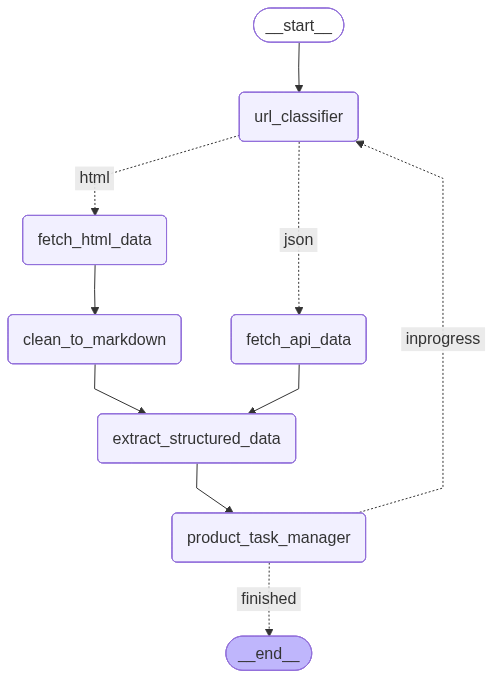

In [54]:
from IPython.display import Image

display(Image(compiled_graph.get_graph().draw_mermaid_png()))

### Running

In [2]:
inputs = {
    "messages": [
        {
            "role": "user", 
            "content": "Use this url to extract at only 10 books http://books.toscrape.com/ and from the following api  get 10 products at least https://api.escuelajs.co/api/v1/products return both products a single list"
        }
    ]
}

compiled_graph.invoke(
inputs
)

NameError: name 'compiled_graph' is not defined